<a href="https://colab.research.google.com/github/liv3812/vibes/blob/main/Frequencia_natural_e_amortecida_Weider.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

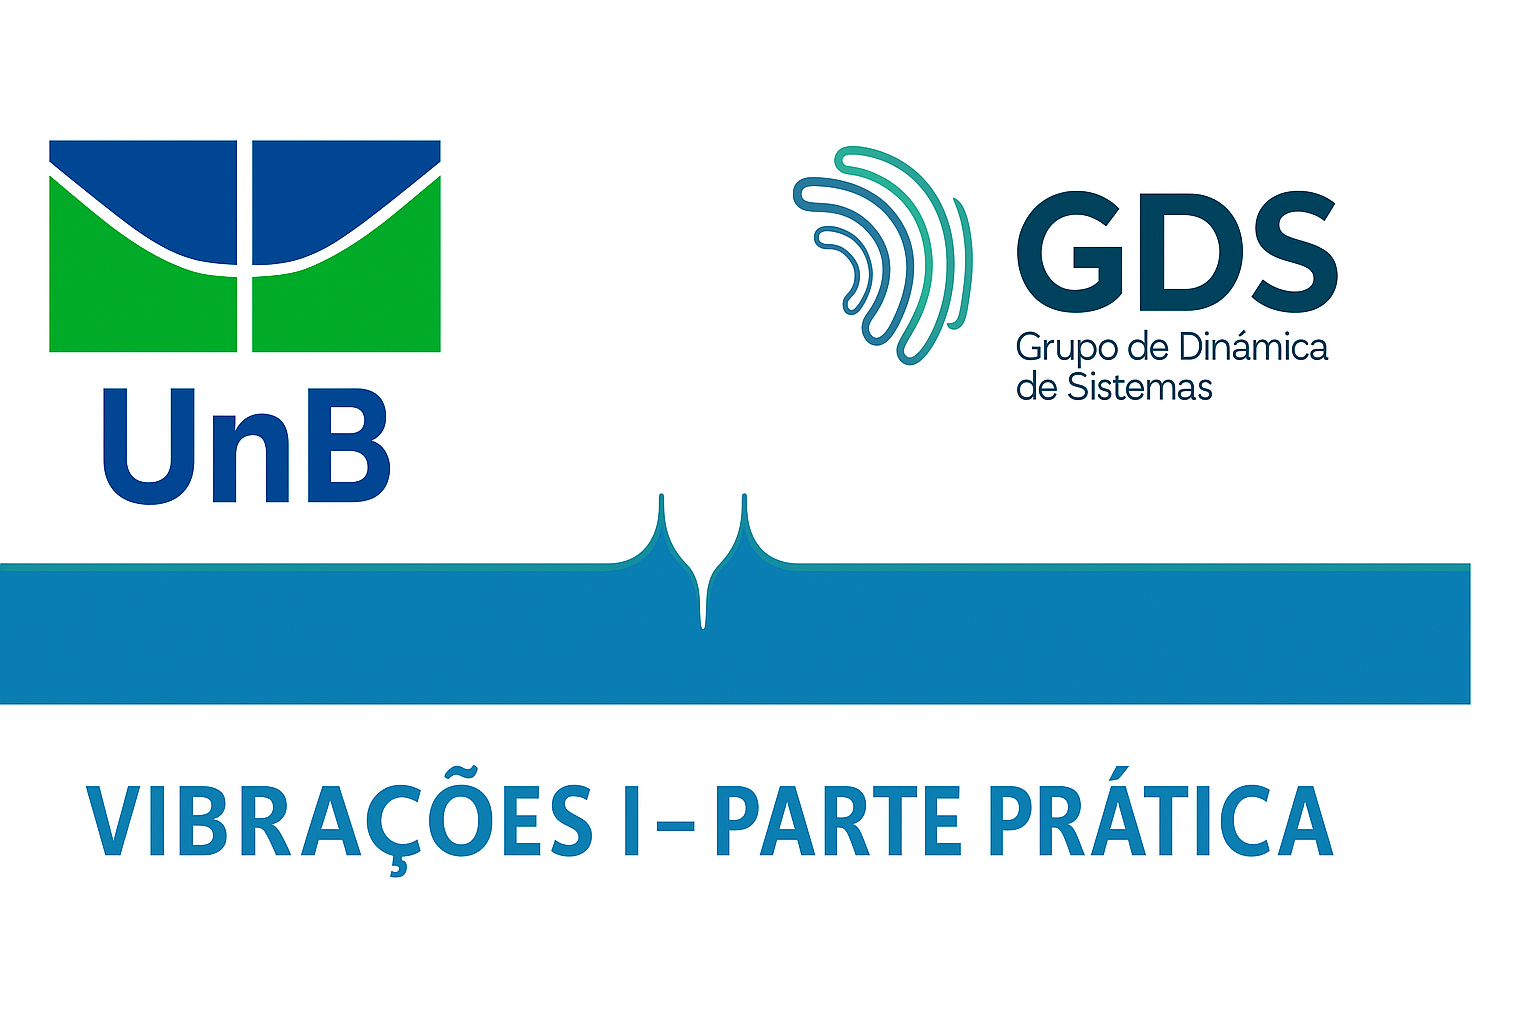

# Vibração Livre Amortecida

A equação do movimento de um oscilador de 1 Grau de Liberdade com amortecimento viscoso e atrito seco é dada por:

$$
m \ddot{u}(t) + c \dot{u} + F_\mu sign(\dot{u}) + k u(t) = 0
$$


onde
$ m $ é a massa $[kg]$,
$ c $ é o coeficiente de amortecimento viscoso $[N s/m]$,
$ F_\mu $ é a magnitude do atrito seco $[N]$,
$ k $ é a rigidez $[N/m]$, e
$ u $ é o deslocamento.

ou ainda,

$$
\ddot{x}(t) + 2 \xi \omega_n \dot{x} + F_\mu sign(\dot{u})/m + \omega_n^2 x(t) = 0
$$

onde
$\omega_n$ é a frequência natural $[rad/s]$ e
$\xi $ é a razão de amortecimento $[adim]$.



## Informações para o relatório

- Para identificar o amortecimento presente é necessário avaliar o tipo de decaimento das amplitudes.

- Identifique os máximos do deslocamento e avalie a razão $u_i/u_{i+1}$ e o valor de $\Delta u_i = u_i-u_{i+1}$ ao longo de toda a resposta para avaliar o tipo de amortecimento presente.

- De acordo com o tipo de amortecimento, use a técnica de decremento adequada. No caso de amortecimneto viscoso, use a técnica da envoltória.

- Identifique a frequência natural amortecida e frequência natural a partir da resposta experimental obtida.

- De posse dos valores identificados, compare a resposta no tempo obtida experimentalmente com a analítica ou numérica utilizando os parâmetros identificados experimentalmente. Apresente os resultados em um mesmo gráfico e comente os resultados obtidos.

- Identifique os coeficientes de rigidezes das molas a partir das medições feitas no laboratório. Calcule a rigidez equivalente e compare com a estimada a partir dos resultados experimentais.

## Implementação

### Importar as Bibliotecas

In [ ]:
# 1GDL
import numpy as np
from math import sin
from math import cos
from math import exp
from math import pi
from scipy.integrate import odeint
from matplotlib import pyplot as plt

In [ ]:
import numpy as np
import pandas as pd
import plotly.graph_objects as go
import os

In [ ]:
f1t2 = pd.read_csv('/content/baja_front_rig2_turma1.txt', sep='\t', skiprows=10, encoding='latin1')
f1t2.set_index('Time (s)', inplace = True)
f1t2.rename(columns={"AI 1/AI 1 (m/s2)": "Acc1 m/s2", "AI 2/AI 2 (m/s2)": "Acc2 m/s2", "AI 3/AI 3 (V)": "Força (V)", "AI 4/AI 4 (V)": "Disp (V)" },  inplace = True)

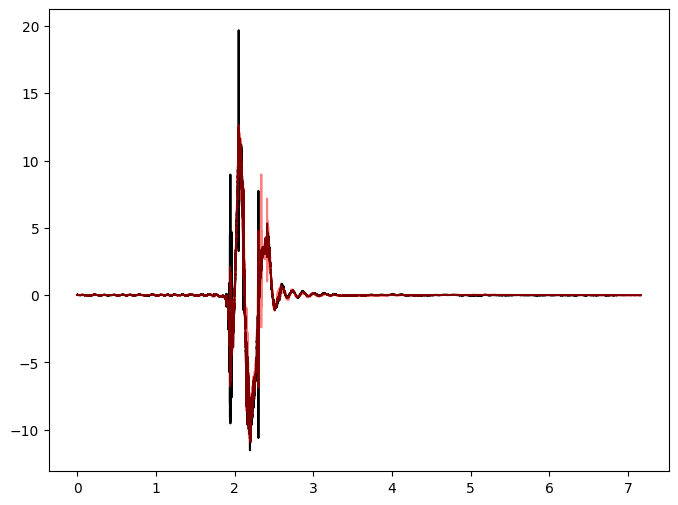

In [ ]:
fig, ax = plt.subplots(figsize=[8,6])

ax.plot(f1t2.index, f1t2['Acc1 m/s2'], 'k', label = 'Acc 1')
ax.plot(f1t2.index, f1t2['Acc2 m/s2'], 'r', label = 'Acc 2', alpha = 0.5)

In [ ]:
#Cortar região de interesse
u_np = np.array(f1t2.loc[2.5:3.2]['Acc1 m/s2'])
time_np = np.array(f1t2.loc[2.5:3.2].index) # Aligned time_np to u_np's range

# Plotando os resultados
fig = go.Figure()
fig.add_trace(go.Scatter(x=time_np, y=u_np, mode='lines', name='Acc1 m/s2 (Filtered)', line=dict(color='red')))

fig.update_layout(
    xaxis_title='Tempo(s)',
    yaxis_title='Aceleração (m/s^2)'
)

fig.show()

### Re-determinar a Envoltória dos Dados Experimentais com Parâmetros Ajustados

Com base no seu feedback, vamos ajustar os parâmetros da função `find_peaks` para identificar um número mais significativo de picos, que representem melhor a envoltória do decaimento. Aumentaremos o parâmetro `distance` para espaçar mais os picos detectados.

### Determinar os Vales (Mínimos) e Picos (Máximos) nos Dados Experimentais Originais

Conforme solicitado, agora vamos identificar e marcar os vales (pontos de mínimo) e os picos (pontos de máximo) diretamente no sinal experimental original `u_np`, sem aplicar a retificação (valor absoluto). Usaremos `find_peaks` no sinal negativo para encontrar esses vales e `find_peaks` no sinal positivo para encontrar os picos.

DataFrame de Extremos Experimentais (Vales e Picos combinados e ordenados por tempo):


,Time,Value,Type
0,2.50230,-0.664725,Peak
1,2.51170,-1.125693,Valley
2,2.58765,0.201282,Valley
3,2.59840,0.847644,Peak
4,2.67305,-0.182409,Valley
5,2.74085,0.352439,Peak
6,2.80225,-0.210518,Valley
7,2.86175,0.266661,Peak
8,2.93485,-0.087592,Valley
9,2.94095,-0.060585,Peak


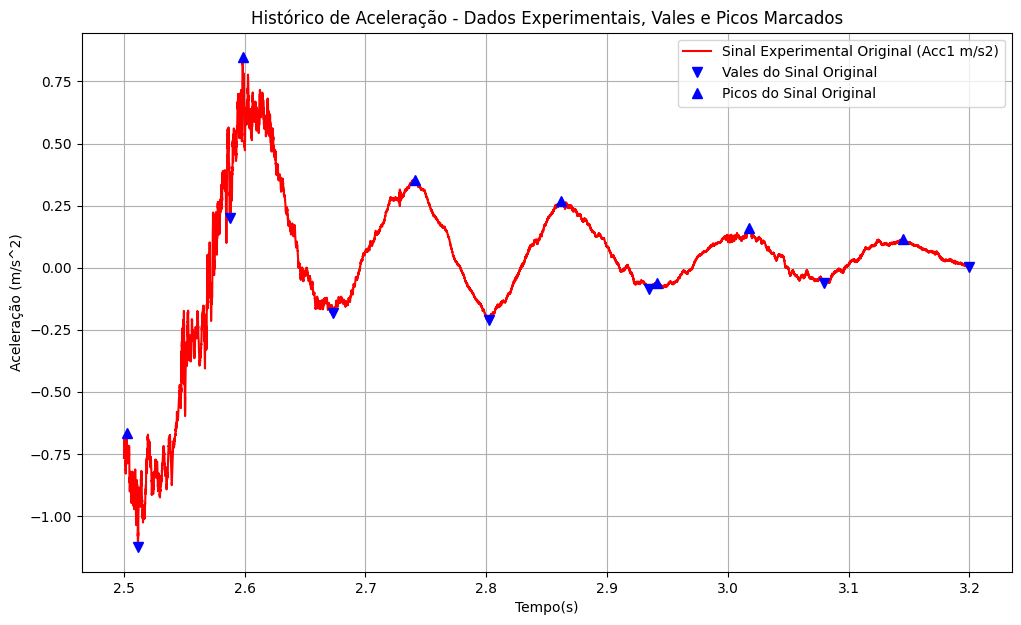

Tempos dos vales do sinal experimental original: [2.5117  2.58765 2.67305 2.80225 2.93485 3.07945 3.1997 ]
Valores dos vales do sinal experimental original: [-1.12569284  0.20128164 -0.18240876 -0.21051803 -0.08759215 -0.06179053
  0.00141474]
Número de vales detectados: 7

Tempos dos picos do sinal experimental original: [2.5023  2.5984  2.74085 2.86175 2.94095 3.0175  3.1449 ]
Valores dos picos do sinal experimental original: [-0.66472512  0.84764415  0.35243854  0.2666612  -0.06058453  0.15818423
  0.11506943]
Número de picos detectados: 7


In [ ]:
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
import pandas as pd # Import pandas
import numpy as np # Import numpy for np.pad

# u_np e time_np já foram definidos anteriormente

# 1. Encontrar os vales no sinal original
# Para encontrar vales com find_peaks, aplicamos a função no negativo do sinal.
# O 'distance' é ajustado para capturar os vales principais, similar aos picos da envoltória.
valleys_indices, _ = find_peaks(-u_np, distance=1500) # Reutilizando a distância ajustada anteriormente

u_valleys_exp = u_np[valleys_indices]
time_valleys_exp = time_np[valleys_indices]

# 2. Encontrar os picos no sinal original
# Usamos o mesmo 'distance' para manter a consistência com a detecção de vales.
peaks_indices, _ = find_peaks(u_np, distance=1500) # Reutilizando a distância ajustada anteriormente

u_peaks_exp = u_np[peaks_indices]
time_peaks_exp = time_np[peaks_indices]

# Combine peaks and valleys into a single DataFrame
# Create DataFrames for valleys and peaks separately
df_valleys = pd.DataFrame({
    'Time': time_valleys_exp,
    'Value': u_valleys_exp,
    'Type': 'Valley'
})

df_peaks = pd.DataFrame({
    'Time': time_peaks_exp,
    'Value': u_peaks_exp,
    'Type': 'Peak'
})

# Concatenate and sort by time
experimental_extrema = pd.concat([df_valleys, df_peaks]).sort_values(by='Time').reset_index(drop=True)

print("DataFrame de Extremos Experimentais (Vales e Picos combinados e ordenados por tempo):")
display(experimental_extrema)

# Plotting the results with marked peaks and valleys from the combined DataFrame
plt.figure(figsize=(12, 7))
plt.plot(time_np, u_np, 'r-', label='Sinal Experimental Original (Acc1 m/s2)')

# Plot valleys
plt.plot(experimental_extrema[experimental_extrema['Type'] == 'Valley']['Time'],
         experimental_extrema[experimental_extrema['Type'] == 'Valley']['Value'],
         'bv', markersize=7, label='Vales do Sinal Original')

# Plot peaks
plt.plot(experimental_extrema[experimental_extrema['Type'] == 'Peak']['Time'],
         experimental_extrema[experimental_extrema['Type'] == 'Peak']['Value'],
         'b^', markersize=7, label='Picos do Sinal Original') # Peaks in blue 'b^'

plt.title('Histórico de Aceleração - Dados Experimentais, Vales e Picos Marcados')
plt.xlabel('Tempo(s)')
plt.ylabel('Aceleração (m/s^2)')
plt.legend()
plt.grid(True)
plt.show()

print("Tempos dos vales do sinal experimental original:", time_valleys_exp)
print("Valores dos vales do sinal experimental original:", u_valleys_exp)
print(f"Número de vales detectados: {len(u_valleys_exp)}")

print("\nTempos dos picos do sinal experimental original:", time_peaks_exp)
print("Valores dos picos do sinal experimental original:", u_peaks_exp)
print(f"Número de picos detectados: {len(u_peaks_exp)}")


### Ajuste Manual dos extremos

Nesta célula, vamos:
1. Partir da detecção original de vales.
2. Inserir o ponto de mínimo do intervalo
3. Gerar o gráfico final.

Pontos de extremos removidos (índices 0-based): [0, 2, 8, 13]

DataFrame de Picos e Vales Experimentais (filtrado):


,Time,Value,Type
0,2.51170,-1.125693,Valley
1,2.59840,0.847644,Peak
2,2.67305,-0.182409,Valley
3,2.74085,0.352439,Peak
4,2.80225,-0.210518,Valley
5,2.86175,0.266661,Peak
6,2.94095,-0.060585,Peak
7,3.01750,0.158184,Peak
8,3.07945,-0.061791,Valley
9,3.14490,0.115069,Peak


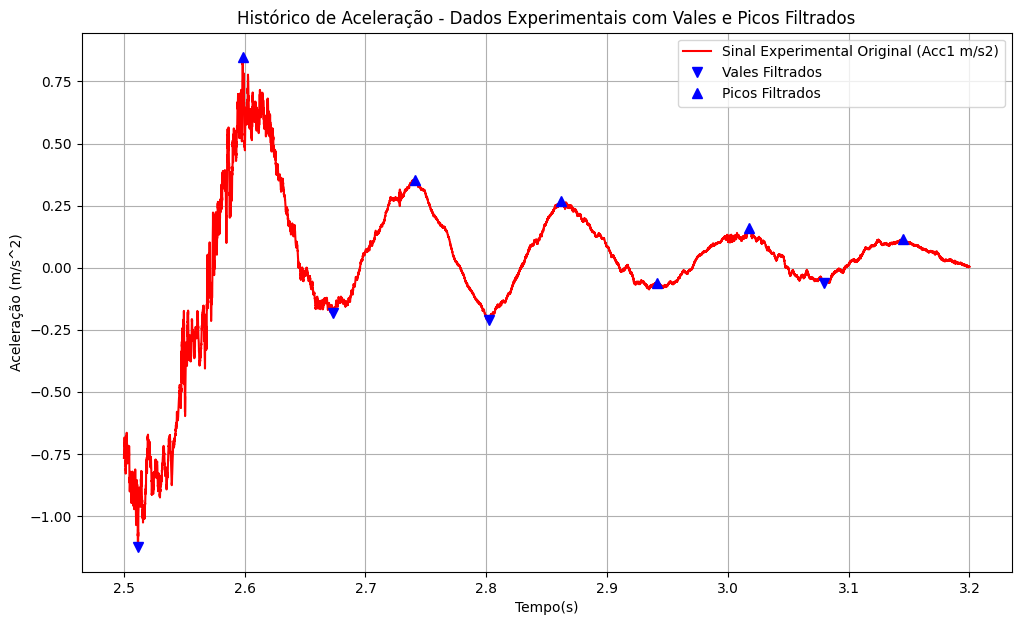

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Criar uma cópia do DataFrame para não modificar o original diretamente se necessário mais tarde
extrema_filtered = experimental_extrema.copy()

# Índices a serem removidos (0-based)
# O usuário pediu para remover o primeiro (index 0), terceiro (index 2), nono (index 8) e décimo quarto (index 13).
# Verificamos se esses índices existem antes de tentar removê-los.
indices_to_remove = [0,2,8,13]

# Filtrar apenas os índices que são válidos para o DataFrame atual
valid_indices_to_remove = [idx for idx in indices_to_remove if idx < len(extrema_filtered)]

# Remover as linhas pelos índices
extrema_filtered = extrema_filtered.drop(index=valid_indices_to_remove)
extrema_filtered = extrema_filtered.reset_index(drop=True) # Resetar o índice após a remoção

print(f"Pontos de extremos removidos (índices 0-based): {valid_indices_to_remove}")
print("\nDataFrame de Picos e Vales Experimentais (filtrado):")
display(extrema_filtered)

# Plotar o sinal original com os extremos filtrados
plt.figure(figsize=(12, 7))
plt.plot(time_np, u_np, 'r-', label='Sinal Experimental Original (Acc1 m/s2)')

# Plot valleys from the filtered DataFrame
plt.plot(extrema_filtered[extrema_filtered['Type'] == 'Valley']['Time'],
         extrema_filtered[extrema_filtered['Type'] == 'Valley']['Value'],
         'bv', markersize=7, label='Vales Filtrados')

# Plot peaks from the filtered DataFrame
plt.plot(extrema_filtered[extrema_filtered['Type'] == 'Peak']['Time'],
         extrema_filtered[extrema_filtered['Type'] == 'Peak']['Value'],
         'b^', markersize=7, label='Picos Filtrados')

plt.title('Histórico de Aceleração - Dados Experimentais com Vales e Picos Filtrados')
plt.xlabel('Tempo(s)')
plt.ylabel('Aceleração (m/s^2)')
plt.legend()
plt.grid(True)
plt.show()


### Ajuste Linear da Envoltória (Dados Experimentais Ajustados)

Utilizaremos os vales selecionados para determinar os coeficientes da reta:
$$ Y = c_0 + c_1 X $$
onde $Y = \ln(|u_{valleys}|)$ e $X = t$.

### Visualização do Decaimento Logarítmico sobre os Dados Experimentais

Antes de analisarmos a reta, vamos reconstruir a curva de decaimento exponencial $a(t) = e^{c_0} \cdot e^{c_1 t}$ a partir dos coeficientes obtidos na regressão e plotá-la sobre o sinal original.

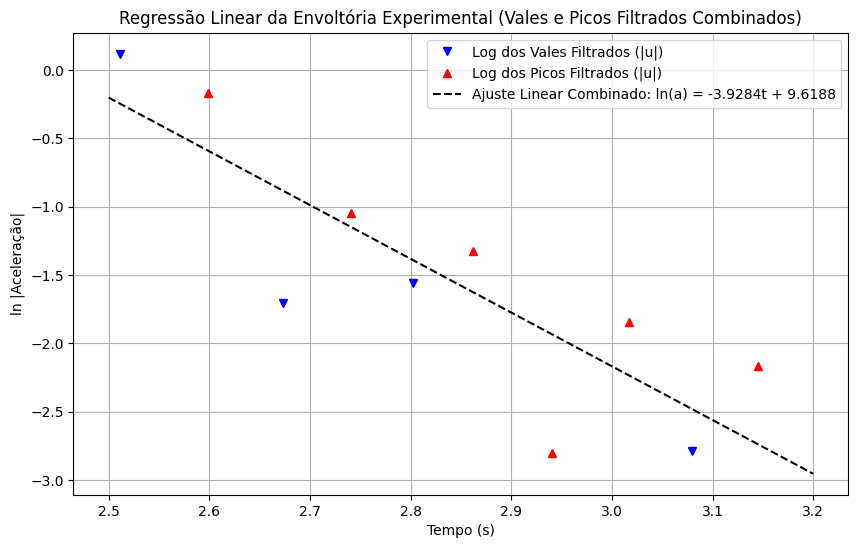

--- Ajuste Linear Combinado (Vales e Picos) ---
Coeficiente angular (c1): -3.9284
Coeficiente linear (c0): 9.6188


In [63]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Prepare data for combined regression using extrema_filtered
y_exp = np.log(np.abs(extrema_filtered['Value']))
x_exp = extrema_filtered['Time']

# Perform a single linear regression (polynomial of degree 1) on the combined data
coefs_exp = np.polyfit(x_exp, y_exp, 1)
c1_exp_fit = coefs_exp[0]  # Slope (corresponds to -xi * wn)
c0_exp_fit = coefs_exp[1]  # Intercept (ln A)

# Generate the regression line for plotting over the full time range of the original signal
# Assuming time_np is globally available from earlier cells
t_reta = np.linspace(time_np.min(), time_np.max(), 100)
y_reta = c1_exp_fit * t_reta + c0_exp_fit

# Plotting the combined data and the single linear fit
plt.figure(figsize=(10, 6))

# Plot filtered valleys directly from extrema_filtered
plt.plot(extrema_filtered[extrema_filtered['Type'] == 'Valley']['Time'],
         np.log(np.abs(extrema_filtered[extrema_filtered['Type'] == 'Valley']['Value'])),
         'bv', label='Log dos Vales Filtrados (|u|)')

# Plot filtered peaks directly from extrema_filtered
plt.plot(extrema_filtered[extrema_filtered['Type'] == 'Peak']['Time'],
         np.log(np.abs(extrema_filtered[extrema_filtered['Type'] == 'Peak']['Value'])),
         'r^', label='Log dos Picos Filtrados (|u|)')

# Plot the single combined regression line
plt.plot(t_reta, y_reta, '--k', label=f'Ajuste Linear Combinado: ln(a) = {c1_exp_fit:.4f}t + {c0_exp_fit:.4f}')

plt.title('Regressão Linear da Envoltória Experimental (Vales e Picos Filtrados Combinados)')
plt.xlabel('Tempo (s)')
plt.ylabel('ln |Aceleração|')
plt.legend()
plt.grid(True)
plt.show()

print(f'--- Ajuste Linear Combinado (Vales e Picos) ---')
print(f'Coeficiente angular (c1): {c1_exp_fit:.4f}')
print(f'Coeficiente linear (c0): {c0_exp_fit:.4f}')

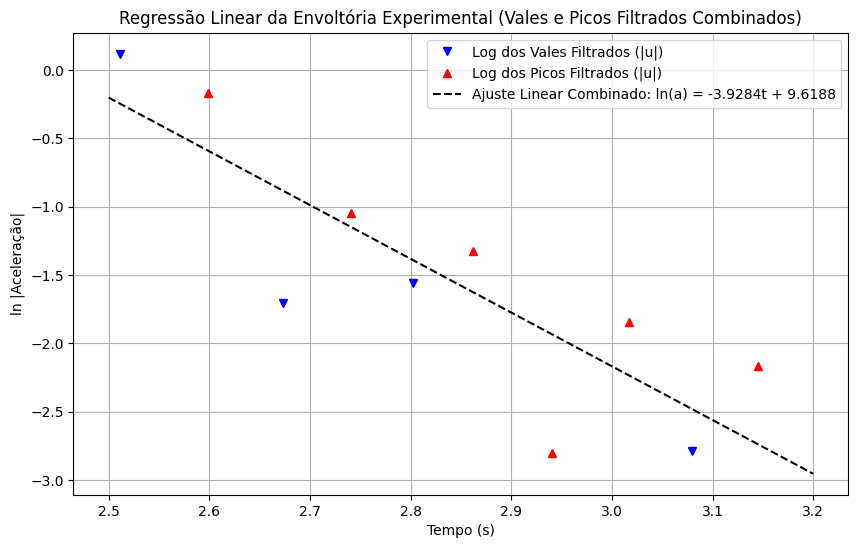

--- Ajuste Linear Combinado (Vales e Picos) ---
Coeficiente angular (c1): -3.9284
Coeficiente linear (c0): 9.6188


In [ ]:
# Filter extrema_filtered to get only valleys and peaks
extrema_filtered_valleys = extrema_filtered[extrema_filtered['Type'] == 'Valley']
extrema_filtered_peaks = extrema_filtered[extrema_filtered['Type'] == 'Peak']

# Combine filtered valleys and peaks into a single DataFrame for regression
combined_extrema_for_regression = pd.concat([extrema_filtered_valleys, extrema_filtered_peaks]).sort_values(by='Time').reset_index(drop=True)

# Calculate the logarithm of the absolute values for regression
y_exp = np.log(np.abs(combined_extrema_for_regression['Value']))
x_exp = combined_extrema_for_regression['Time']

# Perform a single linear regression (polynomial of degree 1) on the combined data
coefs_exp = np.polyfit(x_exp, y_exp, 1)
c1_exp_fit = coefs_exp[0]  # Slope (corresponds to -xi * wn)
c0_exp_fit = coefs_exp[1]  # Intercept (ln A)

# Generate the regression line for plotting
t_reta = np.linspace(time_np.min(), time_np.max(), 100) # Use the full time range for plotting the regression line
y_reta = c1_exp_fit * t_reta + c0_exp_fit

# Plotting the combined data and the single linear fit
plt.figure(figsize=(10, 6))

# Plot filtered valleys
plt.plot(extrema_filtered_valleys['Time'], np.log(np.abs(extrema_filtered_valleys['Value'])),
         'bv', label='Log dos Vales Filtrados (|u|)')

# Plot filtered peaks
plt.plot(extrema_filtered_peaks['Time'], np.log(np.abs(extrema_filtered_peaks['Value'])),
         'r^', label='Log dos Picos Filtrados (|u|)')

# Plot the single combined regression line
plt.plot(t_reta, y_reta, '--k', label=f'Ajuste Linear Combinado: ln(a) = {c1_exp_fit:.4f}t + {c0_exp_fit:.4f}')

plt.title('Regressão Linear da Envoltória Experimental (Vales e Picos Filtrados Combinados)')
plt.xlabel('Tempo (s)')
plt.ylabel('ln |Aceleração|')
plt.legend()
plt.grid(True)
plt.show()

print(f'--- Ajuste Linear Combinado (Vales e Picos) ---')
print(f'Coeficiente angular (c1): {c1_exp_fit:.4f}')
print(f'Coeficiente linear (c0): {c0_exp_fit:.4f}')

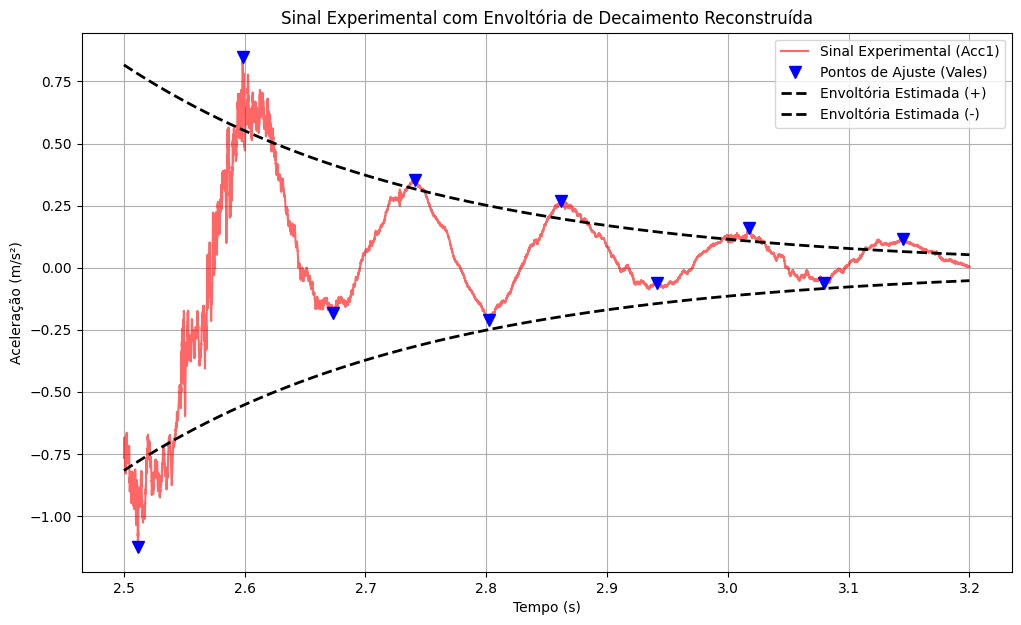

In [66]:
import numpy as np
import matplotlib.pyplot as plt

# coefs_exp[0] é o c1 (inclinação), coefs_exp[1] é o c0 (intercepto)
c1 = coefs_exp[0]
c0 = coefs_exp[1]

# Reconstruindo a envoltória exponencial: a(t) = exp(c0 + c1*t)
t_env = np.linspace(time_np.min(), time_np.max(), 500)
envoltoria_superior = np.exp(c0 + c1 * t_env)
envoltoria_inferior = -envoltoria_superior

# Plotando
plt.figure(figsize=(12, 7))

# 1. Sinal Experimental Original
plt.plot(time_np, u_np, 'r-', alpha=0.6, label='Sinal Experimental (Acc1)')

# 2. Pontos usados no ajuste (Vales)
plt.plot(combined_extrema_for_regression['Time'],combined_extrema_for_regression["Value"], 'bv', markersize=8, label='Pontos de Ajuste (Vales)')

# 3. Curvas de Decaimento (Envoltória)
plt.plot(t_env, envoltoria_superior, '--k', linewidth=2, label='Envoltória Estimada (+)')
plt.plot(t_env, envoltoria_inferior, '--k', linewidth=2, label='Envoltória Estimada (-)')

plt.title('Sinal Experimental com Envoltória de Decaimento Reconstruída')
plt.xlabel('Tempo (s)')
plt.ylabel('Aceleração (m/s²)')
plt.legend()
plt.grid(True)
plt.show()

### Estimativa da Frequência Amortecida ($\omega_d$) e Natural ($\omega_n$)

Calculamos o período $T_d$ como a média das diferenças de tempo entre os picos/vales consecutivos. A partir de $T_d$, obtemos $\omega_d = 2\pi / T_d$. Com o valor de $c_1$ (que representa $\xi\omega_n$), calculamos $\omega_n = \sqrt{\omega_d^2 + c_1^2}$.

In [72]:
import numpy as np

# 1. Calcular os períodos entre os extremos adjacentes (picos e vales)
# Cada delta_t representa meio período amortecido.
deltas_t_half_period = np.diff(combined_extrema_for_regression['Time'])

# 2. Calcular o período médio (Td/2) e o desvio padrão
t_half_period_med = np.mean(deltas_t_half_period)
sigma_t_half_period = np.std(deltas_t_half_period)

# O período amortecido completo (Td) é o dobro do período médio entre extremos
t_d_med = 2 * t_half_period_med

# 3. Calcular a frequência amortecida (wd) em rad/s
# wd = 2 * pi / Td
wd_exp = 2 * np.pi / t_d_med

print(f'Período Amortecido Médio (Td/2, entre extremos): {t_half_period_med:.4f} s')
print(f'Desvio Padrão do (Td/2): {sigma_t_half_period:.4f} s')
print(f'Período Amortecido Médio Completo (Td): {t_d_med:.4f} s')
print(f'Frequência Amortecida (wd): {wd_exp:.4f} rad/s')

Período Amortecido Médio (Td/2, entre extremos): 0.0704 s
Desvio Padrão do (Td/2): 0.0088 s
Período Amortecido Médio Completo (Td): 0.1407 s
Frequência Amortecida (wd): 44.6531 rad/s


In [73]:
# 4. Estimar a Frequência Natural (wn)
# Usamos o c1_exp_fit obtido na célula de regressão anterior
# Note que c1_exp_fit é negativo (decaimento), usamos seu valor absoluto ou o quadrado
wn_exp = np.sqrt(wd_exp**2 + c1_exp_fit**2)

# 5. Calcular a Razão de Amortecimento (xi)
xi_exp = np.abs(c1_exp_fit) / wn_exp

print(f'Frequência Natural Estimada (wn): {wn_exp:.4f} rad/s ({wn_exp/(2*np.pi):.4f} Hz)')
print(f'Razão de Amortecimento Estimada (xi): {xi_exp:.4f}')

Frequência Natural Estimada (wn): 44.8256 rad/s (7.1342 Hz)
Razão de Amortecimento Estimada (xi): 0.0876


<>:51: SyntaxWarning:

invalid escape sequence '\l'

<>:51: SyntaxWarning:

invalid escape sequence '\l'

/tmp/ipykernel_6094/909905122.py:51: SyntaxWarning:

invalid escape sequence '\l'



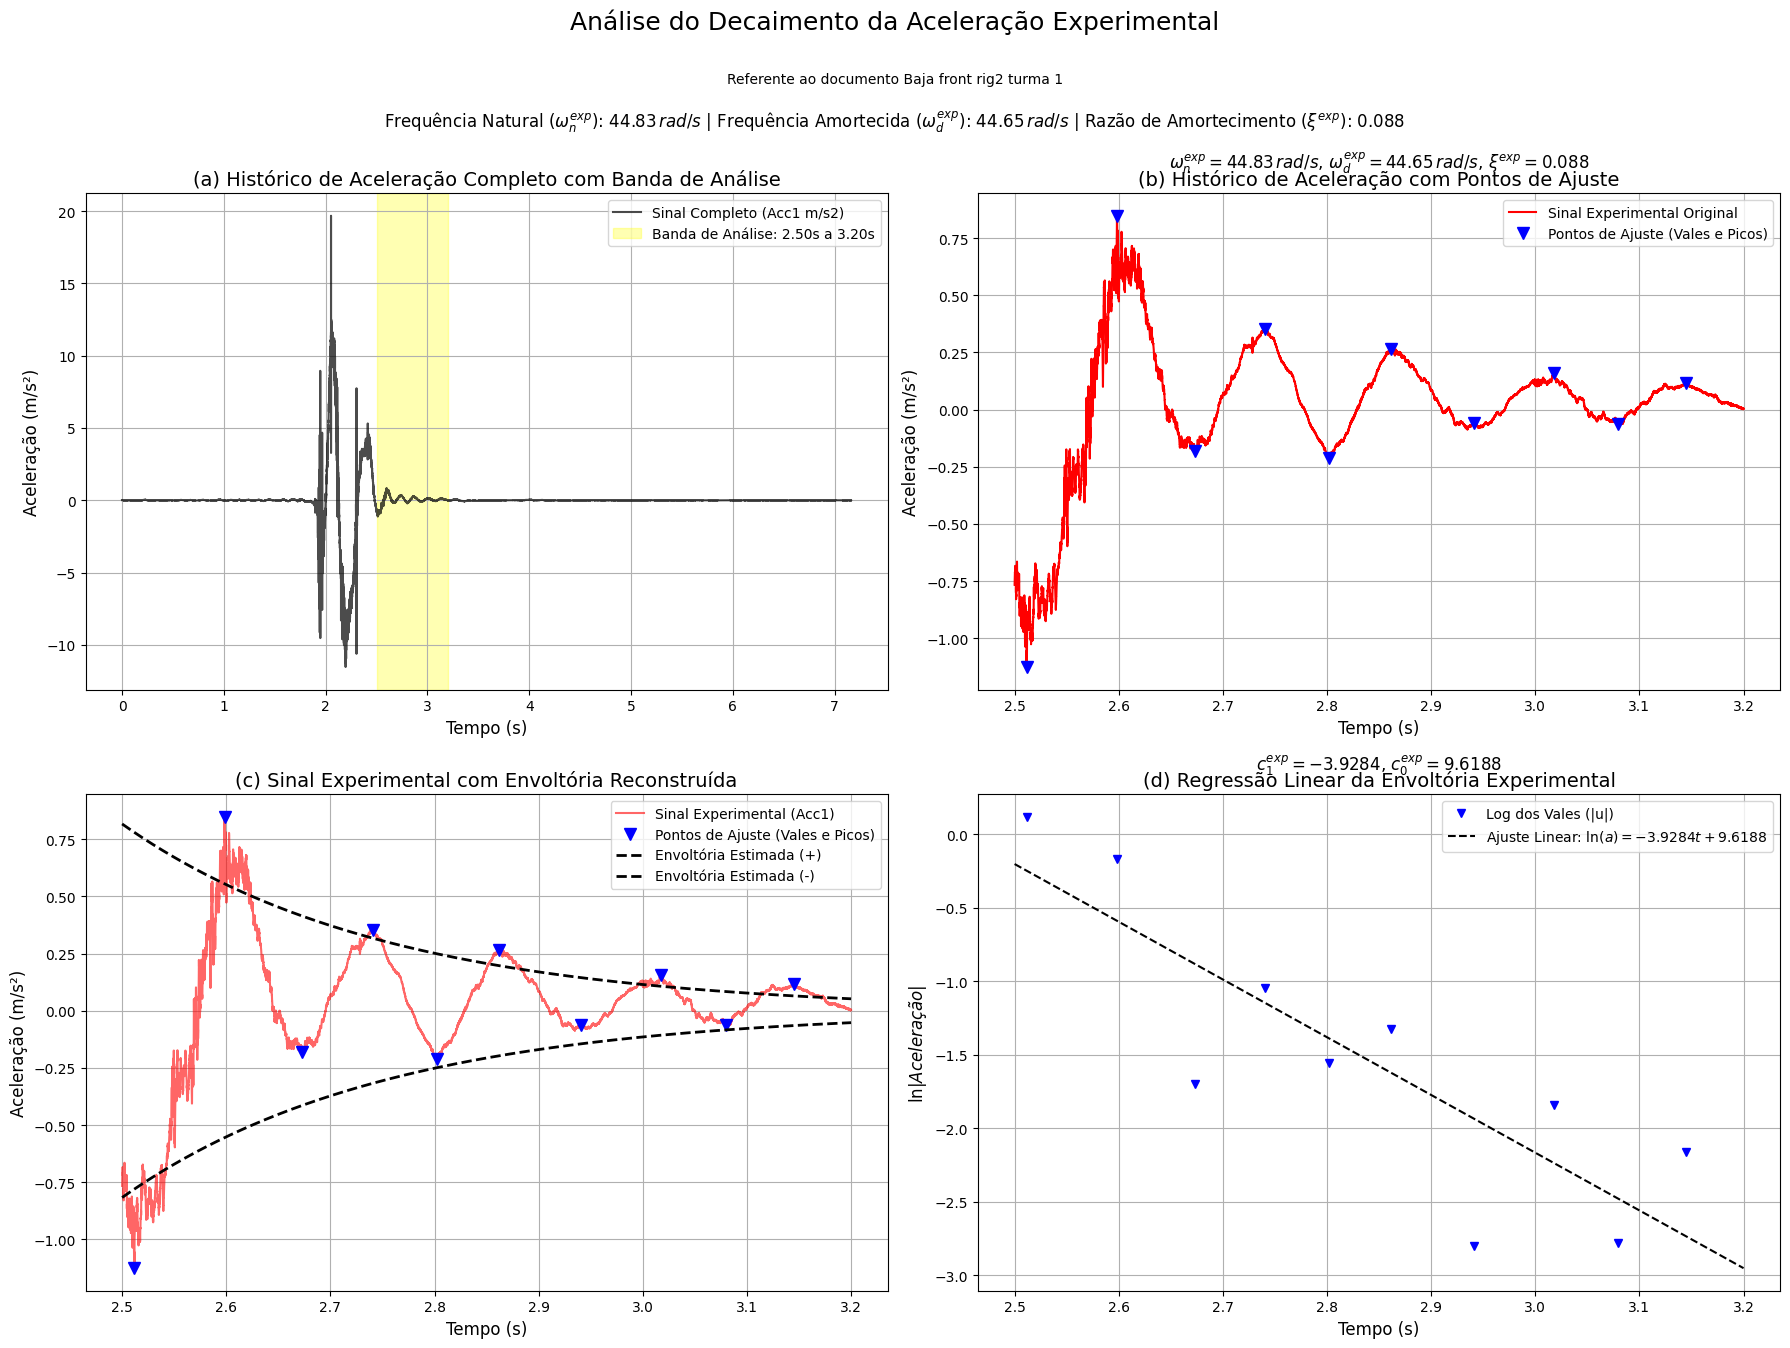

In [75]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks # Ensure find_peaks is available

# Create a figure and a set of subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

# --- Subplot (a): Complete oscillation with highlighted analysis band ----
axes[0, 0].plot(f1t2.index, f1t2['Acc1 m/s2'], 'k-', label='Sinal Completo (Acc1 m/s2)', alpha=0.7)
# Highlight the analysis band
axes[0, 0].axvspan(time_np.min(), time_np.max(), color='yellow', alpha=0.3, label='Banda de Análise: {:.2f}s a {:.2f}s'.format(time_np.min(), time_np.max()))
axes[0, 0].set_title('(a) Histórico de Aceleração Completo com Banda de Análise', fontsize=14)
axes[0, 0].set_xlabel('Tempo (s)', fontsize=12)
axes[0, 0].set_ylabel('Aceleração (m/s²)', fontsize=12)
axes[0, 0].legend()
axes[0, 0].grid(True)


# --- Subplot (b): Adjusted Valleys (from 66c0e644) ---
axes[0, 1].plot(time_np, u_np, 'r-', label='Sinal Experimental Original')
axes[0, 1].plot(combined_extrema_for_regression['Time'], combined_extrema_for_regression['Value'], 'bv', markersize=8, label='Pontos de Ajuste (Vales e Picos)')
axes[0, 1].set_title('(b) Histórico de Aceleração com Pontos de Ajuste', fontsize=14)
axes[0, 1].set_xlabel('Tempo (s)', fontsize=12)
axes[0, 1].set_ylabel('Aceleração (m/s²)', fontsize=12)
axes[0, 1].legend()
axes[0, 1].grid(True)
axes[0, 1].text(0.5, 1.05,
                fr'${{\omega_n^{{exp}}}}={wn_exp:.2f}\,rad/s$, ${{\omega_d^{{exp}}}}={wd_exp:.2f}\,rad/s$, ${{\xi^{{exp}}}}={xi_exp:.3f}$',
                transform=axes[0, 1].transAxes, ha='center', fontsize=12)


# --- Subplot (c) (formerly d): Experimental Signal with Reconstructed Envelope (from 2a948622) ---
# Variables t_env, envoltoria_superior, envoltoria_inferior are already in kernel state
axes[1, 0].plot(time_np, u_np, 'r-', alpha=0.6, label='Sinal Experimental (Acc1)')
axes[1, 0].plot(combined_extrema_for_regression['Time'], combined_extrema_for_regression['Value'], 'bv', markersize=8, label='Pontos de Ajuste (Vales e Picos)')
axes[1, 0].plot(t_env, envoltoria_superior, '--k', linewidth=2, label='Envoltória Estimada (+)')
axes[1, 0].plot(t_env, envoltoria_inferior, '--k', linewidth=2, label='Envoltória Estimada (-)')
axes[1, 0].set_title('(c) Sinal Experimental com Envoltória Reconstruída', fontsize=14)
axes[1, 0].set_xlabel('Tempo (s)', fontsize=12)
axes[1, 0].set_ylabel('Aceleração (m/s²)', fontsize=12)
axes[1, 0].legend()
axes[1, 0].grid(True)


# --- Subplot (d) (formerly c): Linear Regression of Logarithmic Envelope (from e2689c25) ---
# Variables x_exp, y_exp, t_reta, y_reta, c1_exp_fit, c0_exp_fit are already in kernel state
axes[1, 1].plot(x_exp, y_exp, 'bv', label='Log dos Vales (|u|)')
axes[1, 1].plot(t_reta, y_reta, '--k', label=fr'Ajuste Linear: $\ln(a) = {c1_exp_fit:.4f}t + {c0_exp_fit:.4f}$')
axes[1, 1].set_title('(d) Regressão Linear da Envoltória Experimental', fontsize=14)
axes[1, 1].set_xlabel('Tempo (s)', fontsize=12)
axes[1, 1].set_ylabel('$\ln |Aceleração|$', fontsize=12)
axes[1, 1].legend()
axes[1, 1].grid(True)
axes[1, 1].text(0.5, 1.05,
                fr'$c_1^{{exp}}={c1_exp_fit:.4f}$, $c_0^{{exp}}={c0_exp_fit:.4f}$',
                transform=axes[1, 1].transAxes, ha='center', fontsize=12)


plt.tight_layout(rect=[0, 0.03, 1, 0.9]) # Adjust layout to prevent overlap, leaving space for a suptitle and additional text below
fig.suptitle('Análise do Decaimento da Aceleração Experimental', fontsize=18, y=0.99) # Overall title

# Add the frequencies and xi below the main title
plt.figtext(0.5, 0.94,  # Position: 0.5 horizontal, 0.94 vertical (just below suptitle)
            fr'Referente ao documento Baja front rig2 turma 1',
            ha='center', va='center', fontsize=10)
plt.figtext(0.5, 0.91,  # Position: 0.5 horizontal, 0.91 vertical (just below suptitle)
            fr'Frequência Natural ($\omega_n^{{exp}}$): ${wn_exp:.2f}\,rad/s$ | '
            fr'Frequência Amortecida ($\omega_d^{{exp}}$): ${wd_exp:.2f}\,rad/s$ | '
            fr'Razão de Amortecimento ($\xi^{{exp}}$): ${xi_exp:.3f}$',
            ha='center', va='center', fontsize=12)

plt.show()